In [22]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet201
from tensorflow.keras.models import Model,load_model
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import os
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
from transformers import pipeline
from tensorflow.keras.preprocessing import image
import google.generativeai as genai
import shutil
from kaggle_secrets import UserSecretsClient
import base64
import textwrap
# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [ ]:
# pip install fastapi uvicorn python-multipart pillow

In [ ]:

print(os.listdir('/kaggle/working'))

In [ ]:
print(os.listdir('/kaggle/input/models/trngvnthin/models/keras/default/1/best_model.keras'))

# Kiểm tra GPU

In [2]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        print(gpu.name)
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    print("No gpu devices found")
    

/physical_device:GPU:0
/physical_device:GPU:1


In [23]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 128
NUM_CLASSES = 5 

In [24]:
train_dir = '/kaggle/input/datasets/trngvnthin/dataset/DataSet/train'
valid_dir = '/kaggle/input/datasets/trngvnthin/dataset/DataSet/valid'
test_dir  = '/kaggle/input/datasets/trngvnthin/dataset/DataSet/test'

# Tiền xử lý ảnh

In [ ]:
train_data_gen = ImageDataGenerator(
    rescale=1./255
#     # horizontal_flip=True,          # lật ngang
#     # vertical_flip=False,           # không lật dọc (ảnh X-quang không hợp lý)
#     # rotation_range=15,             # xoay ±15 độ
#     # brightness_range=[0.8, 1.2],   # độ sáng ±20%
#     # fill_mode='nearest'            # điền pixel khi xoay/dịch
)
valid_data_gen = ImageDataGenerator(rescale=1./255)
test_data_gen = ImageDataGenerator(rescale=1./255)

train_generator = train_data_gen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse'
)

valid_generator = valid_data_gen.flow_from_directory(
    valid_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse'
)

test_generator = test_data_gen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    shuffle=False
)

Found 25136 images belonging to 5 classes.
Found 2812 images belonging to 5 classes.
Found 1649 images belonging to 5 classes.


# Dùng class_weight tăng độ chú ý cho các lớp ít dữ liệu

In [ ]:
train_labels = train_generator.classes
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(train_labels), y=train_labels)
class_weights = dict(enumerate(class_weights))

# Model training

In [ ]:
pretrained_model = DenseNet201(weights='imagenet', include_top=False, input_shape=[*IMG_SIZE, 3])
pretrained_model.trainable = True

inp = Input(shape=(*IMG_SIZE, 3))
densenet = pretrained_model(inp)

X = GlobalAveragePooling2D()(densenet)
X = Dense(256, activation='elu')(X)
X = Dropout(0.5)(X)

X = Dense(128, activation='elu')(X)
X = Dropout(0.3)(X)

X = Dense(32, activation='elu')(X)

out = Dense(NUM_CLASSES, activation='softmax')(X)

model = Model(inputs=inp, outputs=out)

my_callbacks = [
    EarlyStopping(
        min_delta=0.001, 
        monitor='val_loss', 
        patience=20, 
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor='val_loss', 
        factor=0.1, 
        patience=10
    ),
    ModelCheckpoint(
        filepath='/kaggle/working/best_model.keras', 
        monitor='val_loss', 
        save_best_only=True, 
        save_weights_only=False  
    )
]

model.compile(optimizer=tf.keras.optimizers.Adam(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])


74836368/74836368 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


# Training

In [ ]:
history = model.fit(
    train_data_gen,
    validation_data=valid_generator,
    epochs=50,
    class_weight=class_weights,
    callbacks=my_callbacks
)

# Đánh giá modle trên tập test

In [31]:
test_loss, test_acc= model.evaluate(test_generator)
print(f"Test loss: {test_loss:.2f}")
print(f"Test accuracy: {test_acc:.2f}")

13/13 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.9074 - loss: 0.3727 
Test loss: 0.27
Test accuracy: 0.93


# Lấy mẫu dữ liệu bị dự đoán sai

In [ ]:
test_generator.reset()
n_samples = test_generator.samples  

pred_probs   = model.predict(test_generator, verbose=1)
pred_probs   = pred_probs[:n_samples]        # cắt còn 1649
pred_classes = np.argmax(pred_probs, axis=1)
true_classes = test_generator.classes[:n_samples]
class_labels = list(test_generator.class_indices.keys())

# lấy index các mẫu bị phân loại sai
misclassified_idx = np.where(pred_classes != true_classes)[0]

# thông tin các ảnh bị phân loại sai
filenames = test_generator.filenames
misclassified_samples = []
for i in misclassified_idx:
    sample = {
        "file": filenames[i],
        "true_label": class_labels[true_classes[i]],
        "pred_label": class_labels[pred_classes[i]],
        "confidence": float(np.max(pred_probs[i]))
    }
    misclassified_samples.append(sample)


13/13 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step 


# Lưu folder riêng để phân tích

In [33]:
# lưu ảnh vào thư mục theo class thật
output_dir = "/kaggle/working/misclassified"
if os.path.exists(output_dir):
    shutil.rmtree(output_dir)
os.makedirs(output_dir)

for i in misclassified_idx:
    true_label = class_labels[true_classes[i]]
    class_dir = os.path.join(output_dir, true_label)
    os.makedirs(class_dir, exist_ok=True)

    src = os.path.join(test_generator.directory, filenames[i])
    pred_label = class_labels[pred_classes[i]]
    filename = f"pred_{pred_label}__{os.path.basename(filenames[i])}"
    dst = os.path.join(class_dir, filename)
    shutil.copy(src, dst)

print("Đã lưu ảnh vào các thư mục theo class thật:")
for label in class_labels:
    class_dir = os.path.join(output_dir, label)
    if os.path.exists(class_dir):
        count = len(os.listdir(class_dir))
        print(f"  {label}: {count} ảnh")

Đã lưu ảnh vào các thư mục theo class thật:
  Cavity: 13 ảnh
  Fillings: 24 ảnh
  Impacted Tooth: 8 ảnh
  Implant: 10 ảnh
  Normal: 65 ảnh


# Tạo file zip để lưu về máy

In [ ]:
folder_to_download = '/kaggle/working/misclassified' 

# Tạo filf zip
output_filename = '/kaggle/working/wrong_Class'

# Nén thư mục
shutil.make_archive(output_filename, 'zip', folder_to_download)

print(f"Đã nén xong thành file: {output_filename}.zip")

In [ ]:
from IPython.display import FileLink

# Đường dẫn tới file zip 
FileLink(r'wrong_Class.zip')

# Vẽ biểu đồ loss, ACU

In [ ]:
history_dict = history.history

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_dict['accuracy'], label='Training Accuracy')
plt.plot(history_dict['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history_dict['loss'], label='Training Loss')
plt.plot(history_dict['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# Hàm vẽ biểu đồ ma trận nhầm lẫn 

In [34]:
def plot_confusion_matrix(cm, class_names, title='Confusion Matrix'):
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(title)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

# Hàm lấy nhãn thật và kết quả do model dự đoán

In [35]:
def get_predictions_and_labels(generator):
    num_samples = generator.samples
    predictions = []
    labels = []
    generator.reset()
    
    steps = int(np.ceil(num_samples / generator.batch_size))
    
    for _ in range(steps):
        batch_images, batch_labels = next(generator)
        
        batch_predictions = model.predict(batch_images, verbose=0)
        
        batch_pred_labels = np.argmax(batch_predictions, axis=1)
        batch_true_labels = batch_labels
        
        predictions.extend(batch_pred_labels)
        labels.extend(batch_true_labels)
    
    return np.array(labels), np.array(predictions)

In [36]:
class_names = list(valid_generator.class_indices.keys())

# Vẽ ma trận nhầm lẫn trên tập valid và test

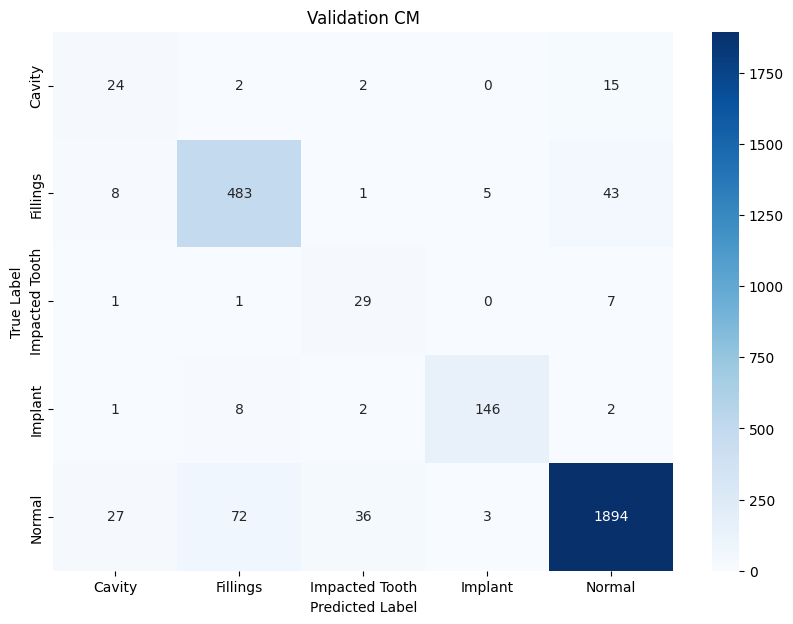

                precision    recall  f1-score   support

        Cavity       0.39      0.56      0.46        43
      Fillings       0.85      0.89      0.87       540
Impacted Tooth       0.41      0.76      0.54        38
       Implant       0.95      0.92      0.93       159
        Normal       0.97      0.93      0.95      2032

      accuracy                           0.92      2812
     macro avg       0.71      0.81      0.75      2812
  weighted avg       0.93      0.92      0.92      2812



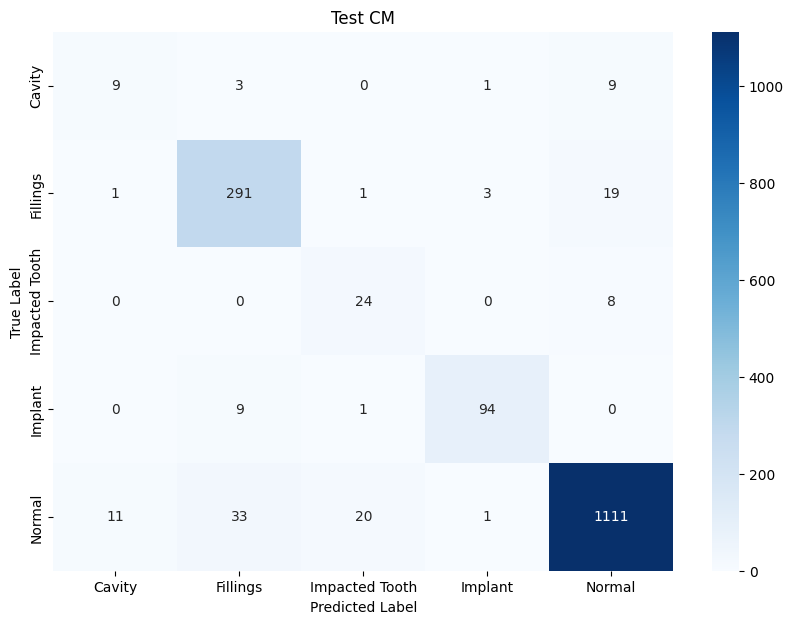

                precision    recall  f1-score   support

        Cavity       0.43      0.41      0.42        22
      Fillings       0.87      0.92      0.89       315
Impacted Tooth       0.52      0.75      0.62        32
       Implant       0.95      0.90      0.93       104
        Normal       0.97      0.94      0.96      1176

      accuracy                           0.93      1649
     macro avg       0.75      0.79      0.76      1649
  weighted avg       0.93      0.93      0.93      1649



In [37]:
y_true_val, y_pred_val = get_predictions_and_labels(valid_generator)

cm_val = confusion_matrix(y_true_val, y_pred_val)
plot_confusion_matrix(cm_val, class_names, title='Validation CM')
print(classification_report(y_true_val, y_pred_val, target_names=class_names))

y_true_test, y_pred_test = get_predictions_and_labels(test_generator)

cm_test = confusion_matrix(y_true_test, y_pred_test)
plot_confusion_matrix(cm_test, class_names, title='Test CM')
print(classification_report(y_true_test, y_pred_test, target_names=class_names))

# Cài đặt API google nếu chưa có

In [ ]:
# pip install google-generativeai

# Tích hợp API Google để đưa ra lời khuyên

In [7]:

# Dự đoán bệnh
def predict_disease(img_path, model, class_names):
    # Load ảnh 
    img = image.load_img(img_path, target_size=(128, 128))
    
    # Convert sang array 
    img_array = image.img_to_array(img)
    
    # Normalize 
    img_array = img_array / 255.0
    # Thêm batch dimension 
    img_array = np.expand_dims(img_array, axis=0)
    
    # Predict 
    pred_probs = model.predict(img_array)
    pred_class = np.argmax(pred_probs)
    
    disease = class_names[pred_class]
    confidence = float(np.max(pred_probs)) 

    return disease, confidence

# Hiển thị hình ành và kết quả dự đoán
def show_prediction(img_path,disease,confidence):
    img = image.load_img(img_path, target_size=(256, 256))
    plt.imshow(img)
    plt.title(f"result: {disease} (confidence: {confidence:.2f})")
    plt.axis('off')
    plt.show()


# Hàm đưa ra lời khuyên sử dụng API gemini

In [8]:
user_secrets = UserSecretsClient()
api_key = user_secrets.get_secret("API")

genai.configure(api_key=api_key)
model_AI = genai.GenerativeModel("gemini-2.5-flash")

In [9]:
def generate_advice(disease):
    if disease != "Normal":
        prompt = f"""
        Tôi có vấn đề về răng miệng: {disease}
        Bạn là một bác sĩ nha khoa.
        Hãy cho tôi 3 lời khuyên ngắn gọn để khắc phục tình trạng đó.
        Yêu cầu định dạng:
        - Đánh số thứ tự 1. 2. 3.
        - Không dùng ký tự * hoặc ** hoặc markdown bất kỳ
        - Chỉ dùng văn bản thuần túy
        """
    else:
        prompt = """
        Bạn là một bác sĩ nha khoa.
        Hãy cho tôi 3 lời khuyên ngắn gọn để giữ răng khỏe đẹp.
        Yêu cầu định dạng:
        - Đánh số thứ tự 1. 2. 3.
        - Không dùng ký tự * hoặc ** hoặc markdown bất kỳ
        - Chỉ dùng văn bản thuần túy
        """
    response = model_AI.generate_content(prompt)
    return response.text

In [ ]:
for m in genai.list_models():
    print(m.name)

# dự đoán và đưa ra lời khuyên

In [30]:
class_names = ['Cavity','Fillings','Impacted Tooth','Implant','Normal']
model = load_model('/kaggle/input/models/trngvnthin/models/keras/default/1/best_model.keras')# load model nếu chưa chạy model

I0000 00:00:1774163334.530285     147 service.cc:152] XLA service 0x794cf40039d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774163334.530327     147 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1774163334.530331     147 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1774163337.235008     147 cuda_dnn.cc:529] Loaded cuDNN version 91002


1/1 ━━━━━━━━━━━━━━━━━━━━ 22s 22s/step


I0000 00:00:1774163350.592156     147 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


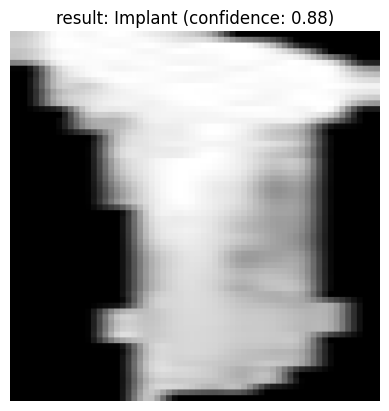

Chào bạn, là bác sĩ nha khoa đây. Với vấn đề về implant, đây là 3 lời khuyên ngắn gọn dành cho bạn:

1.  Duy trì vệ sinh răng miệng thật kỹ lưỡng quanh khu vực implant bằng bàn chải lông mềm và chỉ nha khoa chuyên dụng hoặc bàn chải kẽ mỗi ngày.
2.  Tuân thủ lịch hẹn tái khám định kỳ với nha sĩ để kiểm tra tình trạng implant, xương hàm và thực hiện vệ sinh chuyên nghiệp.
3.  Tránh nhai các thức ăn quá cứng, nghiến răng hoặc các thói quen xấu khác có thể gây áp lực quá mức lên implant và ảnh hưởng đến tuổi thọ của nó.


In [11]:
path = '/kaggle/input/datasets/trngvnthin/dataset/DataSet/test/Implant/0053_jpg.rf.0a39e4969cb730a0e08d415d819e14d9_segment_28.png'

disease,confidence = predict_disease(path, model, class_names)

show_prediction(path,disease,confidence)

print(generate_advice(disease))

if confidence < 0.8:
    print("⚠️Chú ý: Đây chỉ là dự đoán có thể sai.Bạn hãy đến nha khoa để kiểm tra lại nhé")

    

# Hiện thị các ảnh bị dự đoán sai

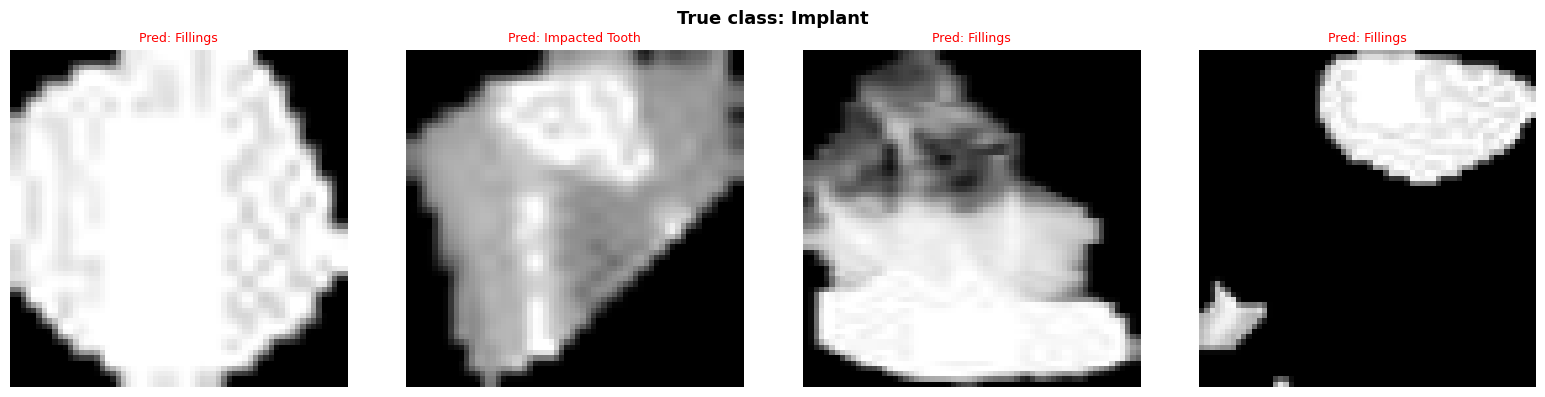

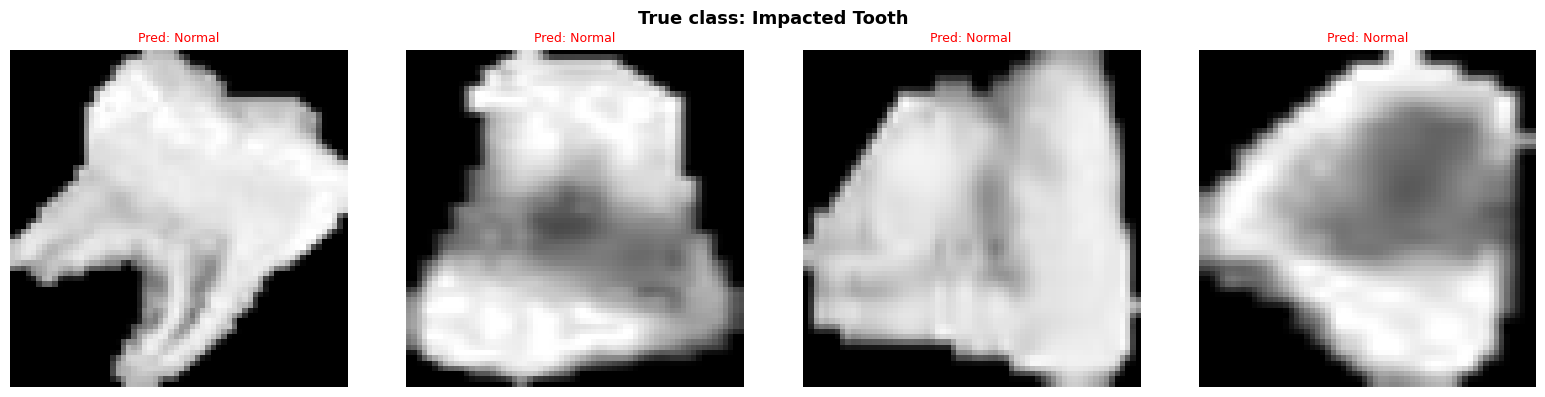

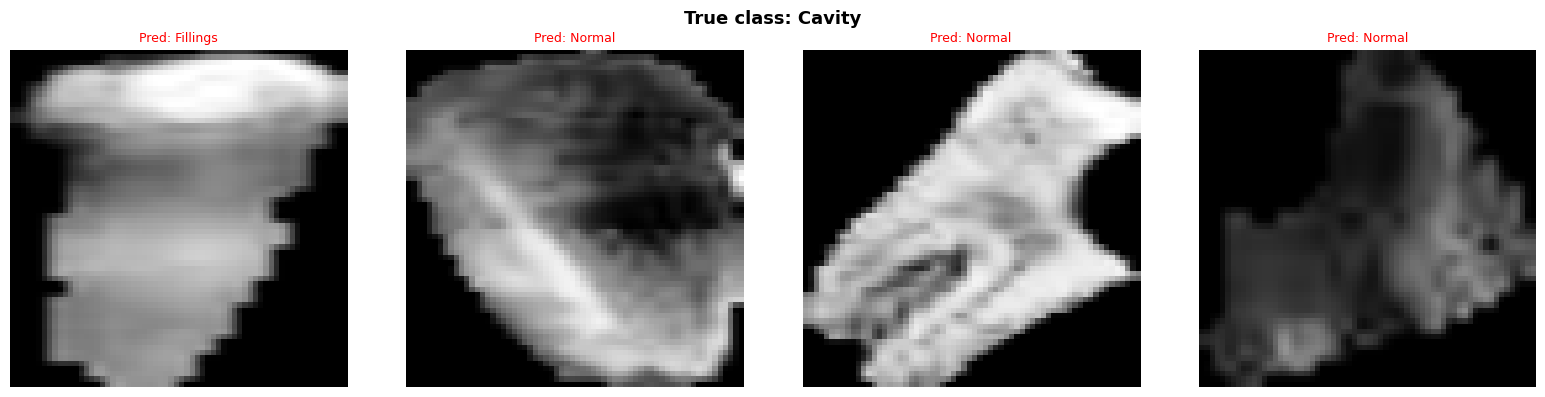

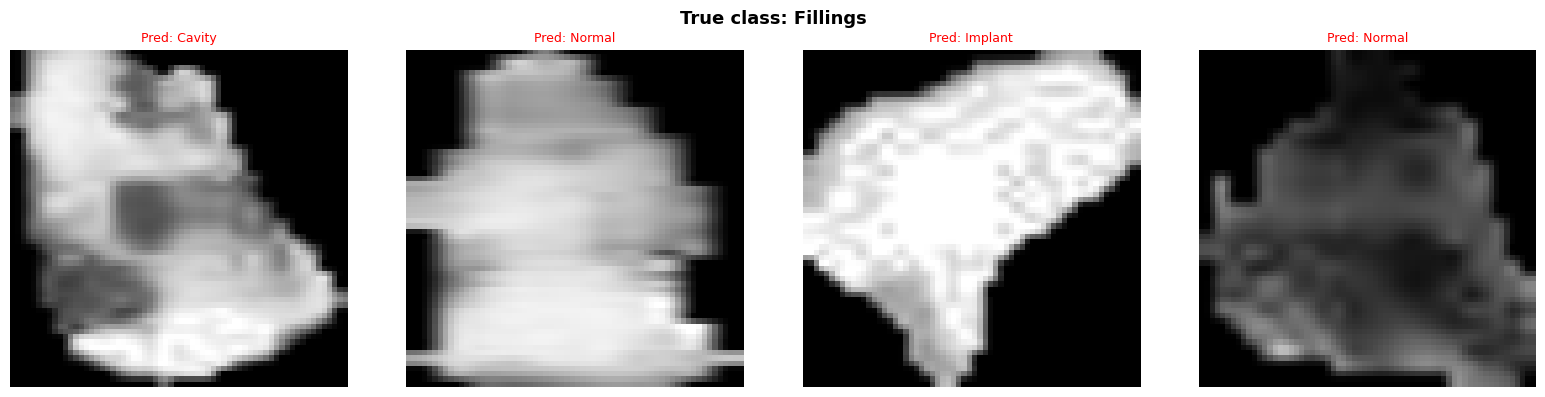

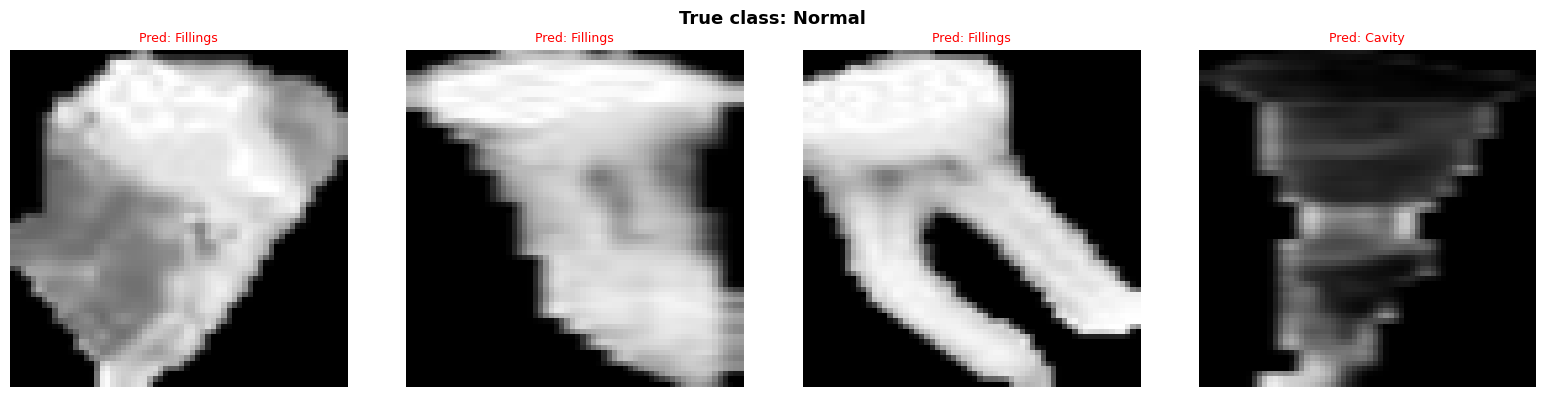

In [39]:
import matplotlib.image as mpimg
misclassified_dir = "/kaggle/working/misclassified/" 
# Hiển thị mẫu ảnh bị phân loại sai theo từng class
N_DISPLAY = 4

for true_class in os.listdir(misclassified_dir):
    class_path = os.path.join(misclassified_dir, true_class)
    if not os.path.isdir(class_path):
        continue

    files = os.listdir(class_path)[:N_DISPLAY]
    if not files:
        continue

    fig, axes = plt.subplots(1, len(files), figsize=(4 * len(files), 4))
    if len(files) == 1:
        axes = [axes]

    fig.suptitle(f"True class: {true_class}", fontsize=13, fontweight='bold')

    for ax, fname in zip(axes, files):
        img_path = os.path.join(class_path, fname)
        img = mpimg.imread(img_path)
        pred_class = fname.split("pred_")[1].split("__")[0]
        ax.imshow(img)
        ax.set_title(f"Pred: {pred_class}", color='red', fontsize=9)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

# Phân tích ảnh bị phân loại sai bằng API-Gemini

In [40]:
def encode_image_to_base64(img_path):
    with open(img_path, "rb") as f:
        return base64.b64encode(f.read()).decode("utf-8")

def analyze_misclassified_image(img_path, true_class, pred_class):
    img_b64 = encode_image_to_base64(img_path)
    
    prompt = f"""
    Đây là ảnh X-quang răng bị phân loại sai bởi mô hình AI.
    - Nhãn thật: {true_class}
    - Mô hình dự đoán nhầm thành: {pred_class}
    
    Với tư cách là bác sĩ nha khoa và chuyên gia AI, hãy phân tích ngắn gọn:
    1. Đặc điểm hình ảnh nào khiến mô hình nhầm lẫn?
    2. Điểm khác biệt giữa {true_class} và {pred_class} trong ảnh X-quang?
    
    Trả lời ngắn gọn, không dùng markdown hay ký tự đặc biệt.
    """
    
    response = model_AI.generate_content([
        {"mime_type": "image/png", "data": img_b64},
        prompt
    ])
    return response.text

 PHÂN TÍCH LÝ DO PHÂN LOẠI SAI 

Class: Implant (10 ảnh sai)


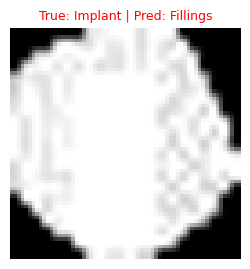

Ảnh: pred_Fillings__0445_jpg.rf.c1b87e7bf4165d062bf6dcfbb56f2c18_segment_354.png
Nhầm: Implant → Fillings
Phân tích:
1. Đặc điểm hình ảnh khiến mô hình nhầm lẫn: Hình ảnh mờ và độ phân giải thấp
khiến các chi tiết nhỏ khó nhận diện. Cả implant và vật liệu trám đều có độ cản
quang rất cao trên X-quang (rất trắng), nên AI có thể nhầm lẫn dựa trên sự tương
đồng về độ sáng và hình dạng không rõ ràng của implant trong ảnh này.  2. Điểm
khác biệt giữa Implant và Fillings trong ảnh X-quang: Implant nằm trong xương
hàm, thay thế chân răng bị mất, thường có hình trụ, côn hoặc vít với cấu trúc rõ
ràng. Trám răng (fillings) nằm trong thân răng còn lại, lấp đầy lỗ sâu hoặc
khuyết tật răng, hình dạng thay đổi tùy thuộc vào vị trí và kích thước lỗ sâu.

Class: Impacted Tooth (8 ảnh sai)


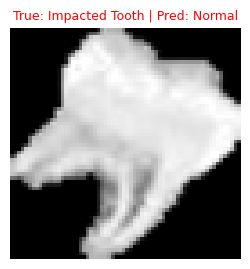

Ảnh: pred_Normal__0161_jpg.rf.a54ad347955227c3eb7d1cfb1af9c51e_segment_218.png
Nhầm: Impacted Tooth → Normal
Phân tích:
1. Đặc điểm hình ảnh nào khiến mô hình nhầm lẫn? Mô hình có thể đã nhận diện cấu
trúc răng cơ bản như hình dạng thân và chân răng, nhưng bỏ qua vị trí bất thường
của răng bị kẹt sâu trong xương hàm và góc mọc lệch hoàn toàn. Nó có thể đã
không đủ mạnh để phân tích mối quan hệ không gian phức tạp của răng với xương và
các răng lân cận.  2. Điểm khác biệt giữa Impacted Tooth và Normal trong ảnh
X-quang? Răng bình thường sẽ mọc thẳng hàng, đúng vị trí trên cung hàm, có
khoảng dây chằng quanh chân răng rõ ràng và xương ổ răng bao bọc hợp lý. Ngược
lại, răng bị kẹt (impacted) sẽ nằm nghiêng, ngang hoặc sâu trong xương hàm,
không thể mọc lên đúng vị trí. Răng bị kẹt thường áp sát hoặc chồng lên răng bên
cạnh, và thường bị bao bọc bởi xương hàm mà không có đủ không gian để mọc.

Class: Cavity (13 ảnh sai)


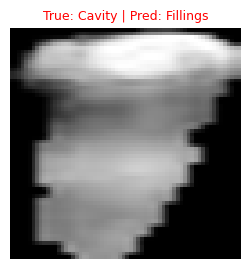

Ảnh: pred_Fillings__0905_jpg.rf.93c5b0e9d232f394f6cedf1c8f3879f4_segment_198.png
Nhầm: Cavity → Fillings
Phân tích:
1. Đặc điểm hình ảnh nào khiến mô hình nhầm lẫn? Mô hình có thể đã nhầm lẫn do
hình dạng, độ sâu hoặc mật độ cản quang của vùng sâu răng có đặc điểm tương tự
với một vết hàn composite cũ hoặc loại không cản quang, đặc biệt nếu vùng sâu
răng có bờ tương đối rõ nét.  2. Điểm khác biệt giữa Cavity và Fillings trong
ảnh X-quang? Sâu răng (Cavity) thường xuất hiện dưới dạng vùng tối (cản quang
kém) với bờ không đều, lan tỏa, thể hiện sự mất mô răng. Trong khi đó, hàn răng
(Fillings) kim loại (amalgam) thì rất sáng (cản quang cao) với bờ sắc nét, rõ
ràng. Hàn composite có độ cản quang thay đổi (có thể tối hơn răng nhưng thường
sáng hơn sâu răng nếu có chất cản quang) và có bờ rõ ràng, theo hình dạng đã
được sửa soạn, khác với bờ lan tỏa của sâu răng.

Class: Fillings (24 ảnh sai)


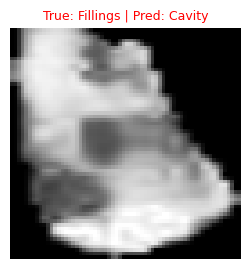

Ảnh: pred_Cavity__0936_jpg.rf.8243a9dd5334cd97eea92b8d4a59439e_segment_208.png
Nhầm: Fillings → Cavity
Phân tích:
1. Đặc điểm hình ảnh nào khiến mô hình nhầm lẫn? Mô hình có thể đã tập trung vào
các vùng tối hơn, có vẻ không đồng nhất hoặc có hình dạng bất thường bên trong
hoặc xung quanh cấu trúc trám sáng. Những vùng này có thể bị hiểu nhầm là dấu
hiệu của sâu răng (cavity) do độ thấu quang cục bộ, mặc dù tổng thể hình ảnh là
một vật liệu cản quang (trám). Sự không đồng nhất về độ cản quang của vật liệu
trám hoặc sâu răng tái phát nhỏ bên dưới có thể là nguyên nhân.  2. Điểm khác
biệt giữa Fillings và Cavity trong ảnh X-quang? Trám răng (Fillings) thường xuất
hiện dưới dạng vùng cản quang (sáng trắng rõ nét) trên ảnh X-quang do vật liệu
trám có mật độ cao hơn mô răng. Chúng thường có viền sắc nét, được xác định rõ
ràng. Sâu răng (Cavity) xuất hiện dưới dạng vùng thấu quang (tối, xám đen) do
mất mô răng. Chúng có hình dạng bất thường, viền thường không rõ ràng và có thể
lan rộng.

Cla

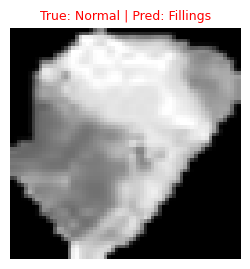

Ảnh: pred_Fillings__0507_jpg.rf.07ca548c6eb4f61c76f1629e7bc26fa4_segment_19.png
Nhầm: Normal → Fillings
Phân tích:
1. Đặc điểm hình ảnh nào khiến mô hình nhầm lẫn? Mô hình có thể đã nhầm lẫn độ
cản quang tự nhiên cao (màu trắng sáng) của men răng, đặc biệt ở phần thân răng,
với vật liệu trám. Men răng khỏe mạnh vốn rất đặc và sáng trên X-quang, điều này
có thể kích hoạt các đặc trưng mà mô hình đã học để nhận diện "Fillings".  2.
Điểm khác biệt giữa Normal và Fillings trong ảnh X-quang? Răng bình thường thể
hiện các lớp rõ ràng: men răng rất sáng ở thân răng, ngà răng sáng vừa, và buồng
tủy/ống tủy tối hơn theo giải phẫu tự nhiên. Vật liệu trám răng xuất hiện dưới
dạng các vùng cực kỳ sáng, thường có hình dạng rõ ràng, nằm *bên trong* cấu trúc
răng và đối lập mạnh mẽ với ngà răng xung quanh, không tuân theo giải phẫu tự
nhiên của tủy răng.



In [ ]:

print(" PHÂN TÍCH LÝ DO PHÂN LOẠI SAI \n")

MAX_PER_CLASS = 1  # phân tích tối đa 1 ảnh mỗi class để tiết kiệm API quota

for true_class in os.listdir(misclassified_dir):
    class_path = os.path.join(misclassified_dir, true_class)
    if not os.path.isdir(class_path):
        continue

    files = os.listdir(class_path)[:MAX_PER_CLASS]
    print(f"{'='*50}")
    print(f"Class: {true_class} ({len(os.listdir(class_path))} ảnh sai)")
    print(f"{'='*50}")

    for fname in files:
        img_path = os.path.join(class_path, fname)
        pred_class = fname.split("pred_")[1].split("__")[0]

        # Hiển thị ảnh
        img = mpimg.imread(img_path)
        plt.figure(figsize=(3, 3))
        plt.imshow(img)
        plt.title(f"True: {true_class} | Pred: {pred_class}", color='red', fontsize=9)
        plt.axis('off')
        plt.show()

        # Phân tích bằng Gemini
        print(f"Ảnh: {fname}")
        print(f"Nhầm: {true_class} → {pred_class}")
        analysis = analyze_misclassified_image(img_path, true_class, pred_class)
        print(f"Phân tích:\n{textwrap.fill(analysis, width=80)}")
        print()